# Module 2 — EDA: Retail Sales Forecasting

Owner: Module 2 (`notebooks/eda.ipynb`, `backend/data_routes.py`)

Reads the **processed** data (`data/processed/model_train.csv` +
`model_holdout.csv`, built by Module 1) via `config.py` — no hardcoded
paths or raw column names. Covers: seasonality (weekly/monthly), the
holiday effect, differences across store types A/B/C, the trend over the
full date range, and a few other patterns worth flagging to the team.

Findings only in this pass — `backend/data_routes.py` comes after these
are sanity-checked.

## 1. Setup and load

In [1]:
import sys
from pathlib import Path

# So `import config` works when the notebook's working directory is
# notebooks/ rather than the repo root.
sys.path.append(str(Path.cwd().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import config

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (11, 4)

In [2]:
train = pd.read_csv(config.PROCESSED_TRAIN_CSV, parse_dates=['date'])
holdout = pd.read_csv(config.PROCESSED_HOLDOUT_CSV, parse_dates=['date'])

print('model_train:', train.shape, train.date.min().date(), '->', train.date.max().date())
print('model_holdout:', holdout.shape, holdout.date.min().date(), '->', holdout.date.max().date())

# Split dates come from config, not hardcoded, per the "read-only after
# Day 1" rule.
print('TRAIN_END_DATE:', config.TRAIN_END_DATE)
print('TEST_START_DATE / TEST_END_DATE:', config.TEST_START_DATE, '/', config.TEST_END_DATE)

model_train: (391919, 24) 2010-02-05 -> 2012-08-17
model_holdout: (29651, 24) 2012-08-24 -> 2012-10-26
TRAIN_END_DATE: 2012-08-17
TEST_START_DATE / TEST_END_DATE: 2012-08-24 / 2012-10-26


**Note on scope:** `model_train` + `model_holdout` together cover the
*full* labeled date range (`2010-02-05` → `2012-10-26`). For EDA on
overall patterns (seasonality, holiday effect, store-type differences)
we want the whole window, so this notebook concatenates them — the
train/holdout split only matters for model evaluation (Modules 3/4/5),
not for exploring what's in the data.

In [3]:
df = pd.concat([train, holdout], ignore_index=True).sort_values(['store_id', 'dept_id', 'date'])
assert df.date.min() == pd.Timestamp('2010-02-05')
assert df.date.max() == pd.Timestamp(config.TEST_END_DATE)
print(f'Combined: {len(df):,} rows, {df.store_id.nunique()} stores, {df.dept_id.nunique()} depts')
df.head()

Combined: 421,570 rows, 45 stores, 81 depts


,store_id,dept_id,date,weekly_sales,is_holiday,temperature,fuel_price,markdown1,markdown2,markdown3,markdown4,markdown5,cpi,unemployment,store_type,store_size,is_negative_sales,day_of_week,month,week_of_year,weekly_sales_lag_1,weekly_sales_lag_4,weekly_sales_roll_mean_4,weekly_sales_roll_std_4
0,1,1,2010-02-05,24924.50,False,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,A,151315,False,4,2,5,NaN,NaN,NaN,NaN
1,1,1,2010-02-12,46039.49,True,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,A,151315,False,4,2,6,24924.50,NaN,NaN,NaN
2,1,1,2010-02-19,41595.55,False,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,A,151315,False,4,2,7,46039.49,NaN,NaN,NaN
3,1,1,2010-02-26,19403.54,False,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106,A,151315,False,4,2,8,41595.55,NaN,NaN,NaN
4,1,1,2010-03-05,21827.90,False,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,A,151315,False,4,3,9,19403.54,24924.5,32990.77,12832.106391


## 2. Quick data check

In [4]:
print(df[config.TARGET_COL].describe())
print()
print(f'Negative {config.TARGET_COL} rows: {df.is_negative_sales.sum()} ({df.is_negative_sales.mean():.2%})')
print(f'Nulls per column:')
print(df.isnull().sum()[df.isnull().sum() > 0])

count    421570.000000
mean      15981.258123
std       22711.183519
min       -4988.940000
25%        2079.650000
50%        7612.030000
75%       20205.852500
max      693099.360000
Name: weekly_sales, dtype: float64

Negative weekly_sales rows: 1285 (0.30%)
Nulls per column:
weekly_sales_lag_1           3331
weekly_sales_lag_4          13134
weekly_sales_roll_mean_4    13134
weekly_sales_roll_std_4     13134
dtype: int64


Per `data_schema.md`, the only nullable columns are the lag/rolling
features (`weekly_sales_lag_1/4`, `weekly_sales_roll_mean_4/std_4`) — those
are NaN for a store/dept's first observed week(s), which is expected and
not a data quality issue. Negative sales (~0.3%) are legitimate returns,
kept as-is.

## 3. Trend over the full date range

Total weekly sales across all stores/depts, `2010-02-05` → `2012-10-26`.

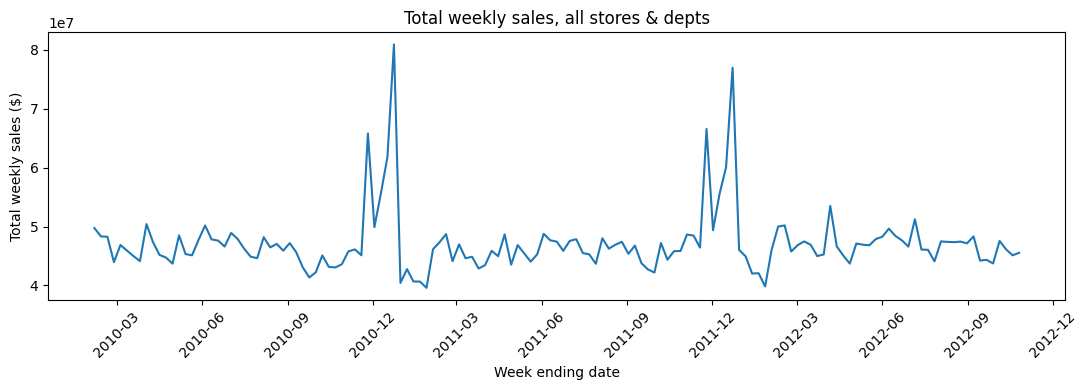

In [5]:
weekly_total = df.groupby('date')[config.TARGET_COL].sum()

fig, ax = plt.subplots()
ax.plot(weekly_total.index, weekly_total.values)
ax.set_title('Total weekly sales, all stores & depts')
ax.set_xlabel('Week ending date')
ax.set_ylabel('Total weekly sales ($)')
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Takeaway:** No strong multi-year growth or decline trend — the series
is essentially flat around its mean with sharp, recurring spikes. The
spikes are annual and land in the same calendar weeks each year
(late Nov / late Dec), which points to holiday effects rather than
underlying business growth. Confirmed in the sections below.

## 4. Seasonality — monthly pattern

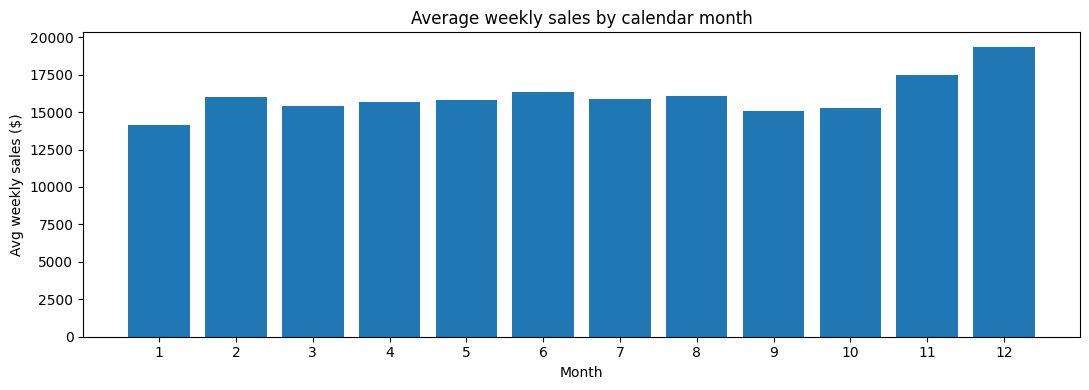

month
12    19355.702141
11    17491.031424
6     16326.137002
8     16062.516933
2     16008.779217
7     15861.419650
5     15776.337202
4     15650.338357
3     15416.657597
10    15243.855576
9     15095.886154
1     14126.075111
Name: weekly_sales, dtype: float64

In [6]:
monthly_avg = df.groupby('month')[config.TARGET_COL].mean()

fig, ax = plt.subplots()
ax.bar(monthly_avg.index, monthly_avg.values)
ax.set_title('Average weekly sales by calendar month')
ax.set_xlabel('Month')
ax.set_ylabel('Avg weekly sales ($)')
ax.set_xticks(range(1, 13))
plt.tight_layout()
plt.show()

monthly_avg.sort_values(ascending=False)

**Takeaway:** December is the clear peak (~+22% vs. the January low),
with a smaller bump in November. Feb–Oct is comparatively flat
(roughly $15.1K–$16.3K avg). This is a December/November effect
specifically, not a broad "second half of year" effect.

## 5. Seasonality — week-of-year pattern

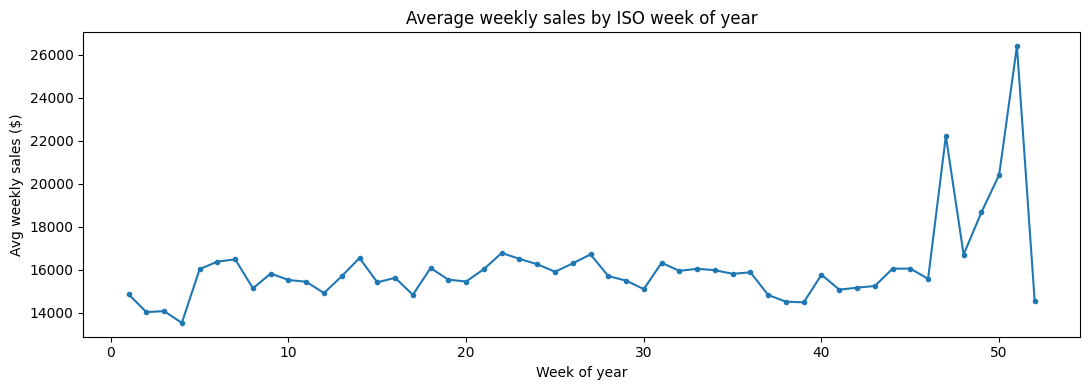

week_of_year
51    26396.399283
47    22220.944538
50    20413.010012
49    18668.667017
22    16779.736413
27    16715.385450
Name: weekly_sales, dtype: float64

In [7]:
weekly_avg = df.groupby('week_of_year')[config.TARGET_COL].mean()

fig, ax = plt.subplots()
ax.plot(weekly_avg.index, weekly_avg.values, marker='o', markersize=3)
ax.set_title('Average weekly sales by ISO week of year')
ax.set_xlabel('Week of year')
ax.set_ylabel('Avg weekly sales ($)')
plt.tight_layout()
plt.show()

weekly_avg.sort_values(ascending=False).head(6)

**Takeaway:** The week-of-year view is sharper than the monthly one —
the very top weeks are ~47 (Thanksgiving) and ~51-52
(Christmas/New Year), each roughly 30-80% above the yearly average
week. This is the same signal as section 4 at finer granularity, and is
the basis for `is_holiday` as a modeling feature.

## 6. Holiday effect

`is_holiday` covers the four Kaggle-flagged holiday weeks: Super Bowl,
Labor Day, Thanksgiving, Christmas.

In [8]:
holiday_avg = df.groupby('is_holiday')[config.TARGET_COL].mean()
holiday_lift_pct = (holiday_avg[True] - holiday_avg[False]) / holiday_avg[False] * 100

print(f'Avg weekly sales, non-holiday weeks: ${holiday_avg[False]:,.2f}')
print(f'Avg weekly sales, holiday weeks:     ${holiday_avg[True]:,.2f}')
print(f'Overall holiday lift: {holiday_lift_pct:.2f}%')

# break out by the specific holiday, since "holiday" isn't one event
df['year'] = df.date.dt.year
holiday_weeks = df[df.is_holiday].groupby('date')[config.TARGET_COL].mean().sort_values(ascending=False)
holiday_weeks

Avg weekly sales, non-holiday weeks: $15,901.45
Avg weekly sales, holiday weeks:     $17,035.82
Overall holiday lift: 7.13%


date
2010-11-26    22403.336705
2011-11-25    22043.563476
2012-02-10    16664.247891
2010-02-12    16352.056032
2012-09-07    16294.692957
2011-02-11    16111.706191
2011-09-09    15809.069483
2010-09-10    15537.758883
2011-12-30    15332.154858
2010-12-31    13738.538566
Name: weekly_sales, dtype: float64

**Takeaway:** The blended holiday lift (~7%) is much smaller than the
visual spikes in section 3 suggest — Thanksgiving/Christmas weeks are
huge outliers, but Super Bowl and Labor Day weeks are close to average
or even slightly below, and they pull the aggregate down. **Anyone using
`holiday_lift_pct` downstream (Module 6 reorder logic, Module 8
`/insights` copy) should know it's a blend of 4 very different events**,
not a single "holidays are +7%" story — Thanksgiving/Christmas weeks
individually run 30-80% above baseline.

## 7. Differences across store types (A/B/C)

In [9]:
type_stats = df.groupby('store_type').agg(
    n_stores=('store_id', 'nunique'),
    avg_store_size=('store_size', 'mean'),
    avg_weekly_sales=(config.TARGET_COL, 'mean'),
    total_sales=(config.TARGET_COL, 'sum'),
).sort_values('avg_weekly_sales', ascending=False)
type_stats

,n_stores,avg_store_size,avg_weekly_sales,total_sales
store_type,,,,
A,22,182231.285486,20099.568043,4.331015e+09
B,17,101818.735827,12237.075977,2.000701e+09
C,6,40535.725286,9519.532538,4.055035e+08


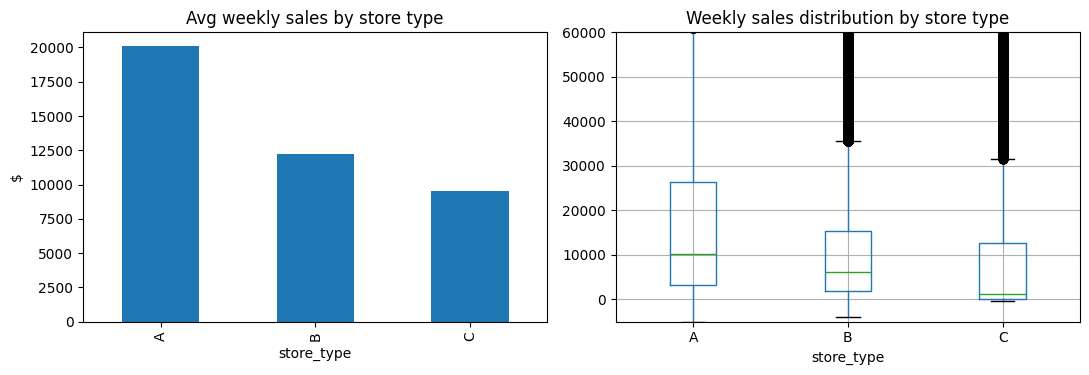

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
df.groupby('store_type')[config.TARGET_COL].mean().plot(kind='bar', ax=axes[0], title='Avg weekly sales by store type')
axes[0].set_ylabel('$')
df.boxplot(column=config.TARGET_COL, by='store_type', ax=axes[1])
axes[1].set_title('Weekly sales distribution by store type')
axes[1].set_ylim(-5000, 60000)  # clip extreme outliers for readability
plt.suptitle('')
plt.tight_layout()
plt.show()

**Takeaway:** Store type tracks store size almost one-to-one — Type A
stores are largest and sell the most per week (~$20.1K avg), Type C
smallest and least (~$9.5K avg), Type B in between. This is close to
what you'd get just from `store_size` alone; worth checking during
feature engineering (Module 1) whether `store_type` adds signal beyond
`store_size`, or is largely redundant with it.

## 8. Top and bottom performing stores

In [11]:
TOP_N = 5  # not pinned by the API contract — flag with the team if a different count is wanted

store_totals = (df.groupby(['store_id', 'store_type', 'store_size'])[config.TARGET_COL]
                .sum().sort_values(ascending=False).reset_index())

print('Top', TOP_N, 'stores by total sales:')
display(store_totals.head(TOP_N))
print('Bottom', TOP_N, 'stores by total sales:')
display(store_totals.tail(TOP_N))

Top 5 stores by total sales:


,store_id,store_type,store_size,weekly_sales
0,20,A,203742,3.013978e+08
1,4,A,205863,2.995440e+08
2,14,A,200898,2.889999e+08
3,13,A,219622,2.865177e+08
4,2,A,202307,2.753824e+08


Bottom 5 stores by total sales:


,store_id,store_type,store_size,weekly_sales
40,38,C,39690,55159626.42
41,36,A,39910,53412214.97
42,5,B,34875,45475688.90
43,44,C,39910,43293087.84
44,33,A,39690,37160221.96


**Takeaway:** Top stores are all Type A with large `store_size`; bottom
stores are a mix of small Type A/B and Type C — size explains most of
the ranking, but not all of it (worth a per-`store_size`-normalized
view later if the team wants "efficiency" rather than raw volume).

## 9. Markdown activity (secondary pattern)

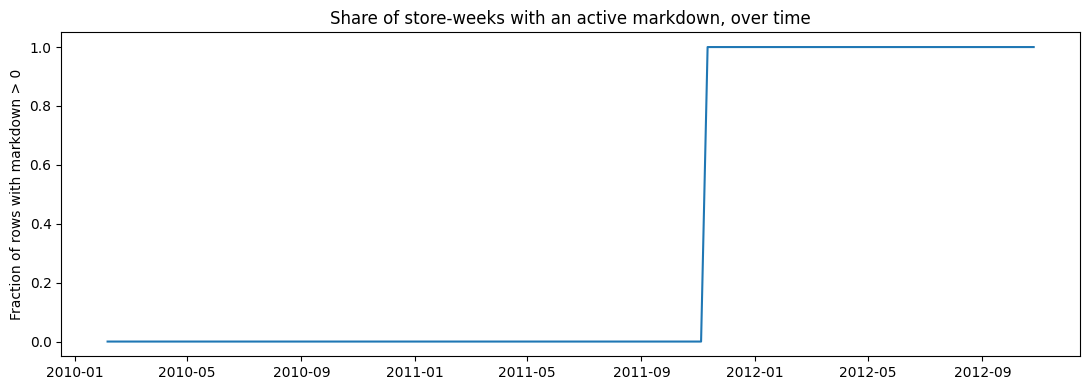

Markdown lift: 1.92%  (active avg $16,177 vs none $15,872)


In [12]:
md_cols = ['markdown1', 'markdown2', 'markdown3', 'markdown4', 'markdown5']
df['any_markdown'] = (df[md_cols].sum(axis=1) > 0)

md_by_date = df.groupby('date')['any_markdown'].mean()
fig, ax = plt.subplots()
ax.plot(md_by_date.index, md_by_date.values)
ax.set_title('Share of store-weeks with an active markdown, over time')
ax.set_ylabel('Fraction of rows with markdown > 0')
plt.tight_layout()
plt.show()

md_avg = df.loc[df.any_markdown, config.TARGET_COL].mean()
no_md_avg = df.loc[~df.any_markdown, config.TARGET_COL].mean()
markdown_lift_pct = (md_avg - no_md_avg) / no_md_avg * 100
print(f'Markdown lift: {markdown_lift_pct:.2f}%  (active avg ${md_avg:,.0f} vs none ${no_md_avg:,.0f})')

**Takeaway:** Markdown data is genuinely zero (not missing-and-filled)
for roughly the first half of the window, then ramps up — visible as
the step change in the plot. Because of this, "no markdown" isn't a
clean control group (it's mostly early-period weeks that couldn't have
had a markdown at all), so `markdown_lift_pct` should be read as
directional, not causal. Confirms the same caveat noted in
`data_schema.md`'s "Update 2026-08-17" section about NaN→0 conflating
"no promo" with "$0 promo".

## 10. Summary for the team

- **Grain:** `(store_id, dept_id, date)`, weekly/Friday-aligned — 45 stores, 81 depts, `2010-02-05` → `2012-10-26`.
- **No secular trend** — sales are flat year-over-year apart from holiday spikes (section 3).
- **December is the seasonal peak** (~+22% vs. January low); the sharpest single-week spikes are Thanksgiving and Christmas specifically (sections 4-5).
- **Blended holiday lift ≈ 7%**, but this hides big variance across the 4 holidays — Thanksgiving/Christmas are large positive outliers, Super Bowl/Labor Day are roughly flat (section 6). Flag to Module 6/8 before they use a single lift number.
- **Store type ≈ store size** — Type A/B/C differences in average sales track store size closely; may be largely redundant as separate features (section 7).
- **Markdown lift (~1.9%) is confounded with time** — markdowns barely existed before late 2011, so the "no markdown" baseline is mostly early-period data, not a clean A/B comparison (section 9).
- **Top-N choice (`TOP_N = 5`)** used for top/bottom store lists isn't specified by the API contract — confirm with the team/frontend before `/data/summary` locks it in.

Next: once these are sanity-checked, `backend/data_routes.py` will expose
the same aggregates (grouped by `store_type`, weekly trend, top/bottom
stores) as `/data/summary`, matching whatever `docs/api_contract.md`
specifies for field names and response shape.